<a href="https://colab.research.google.com/github/Prathvi06172005/Machine-Learning/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

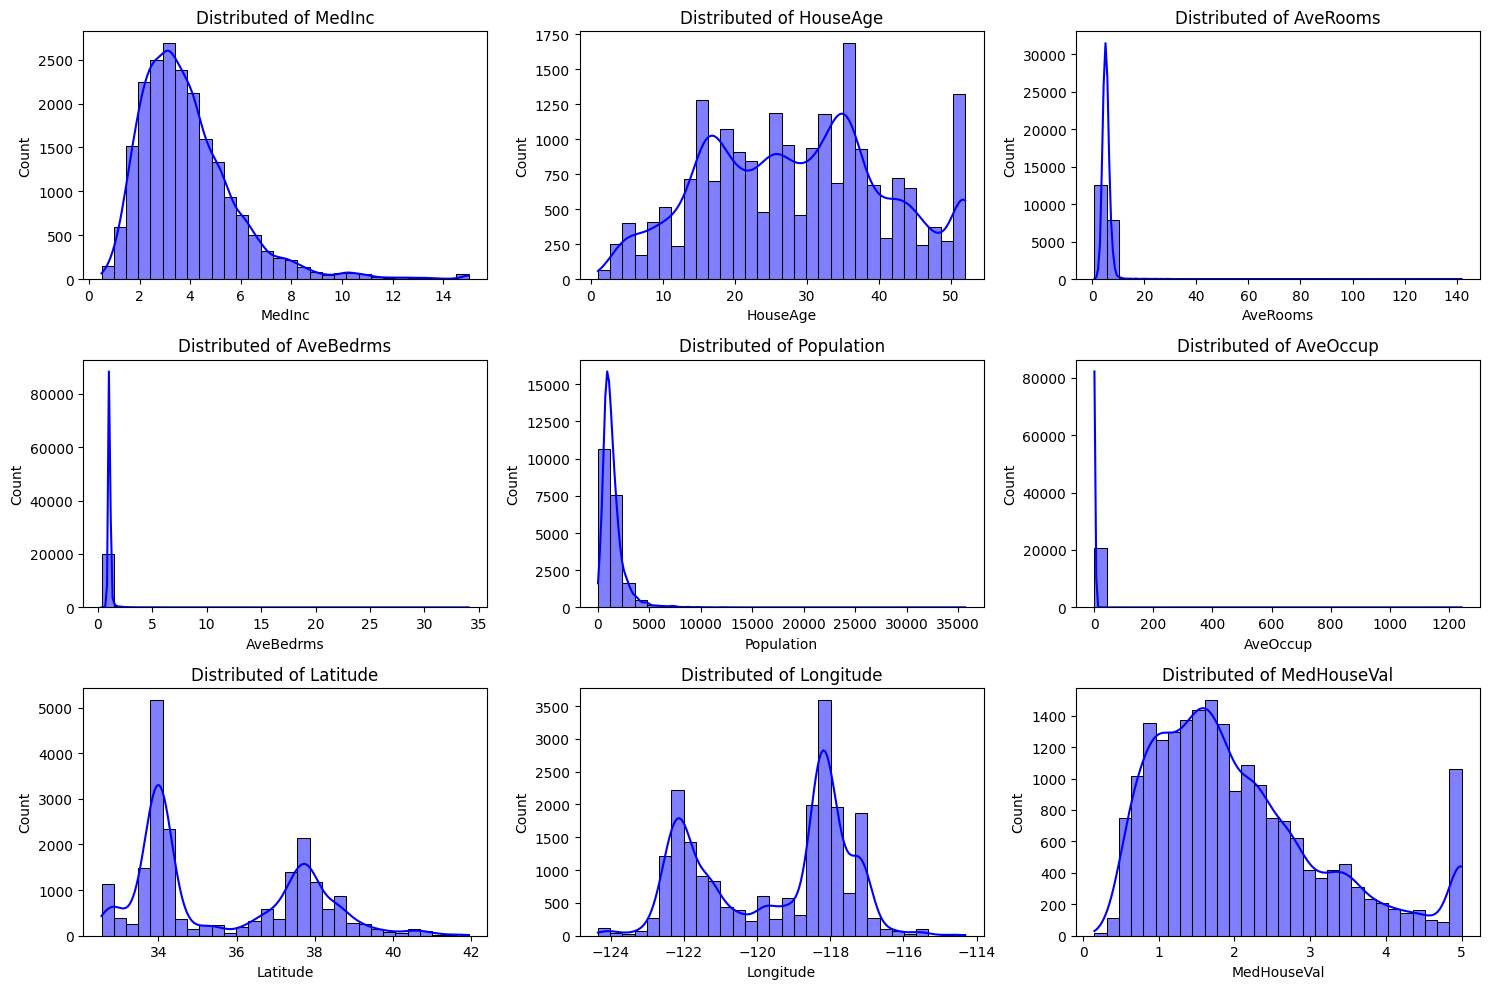

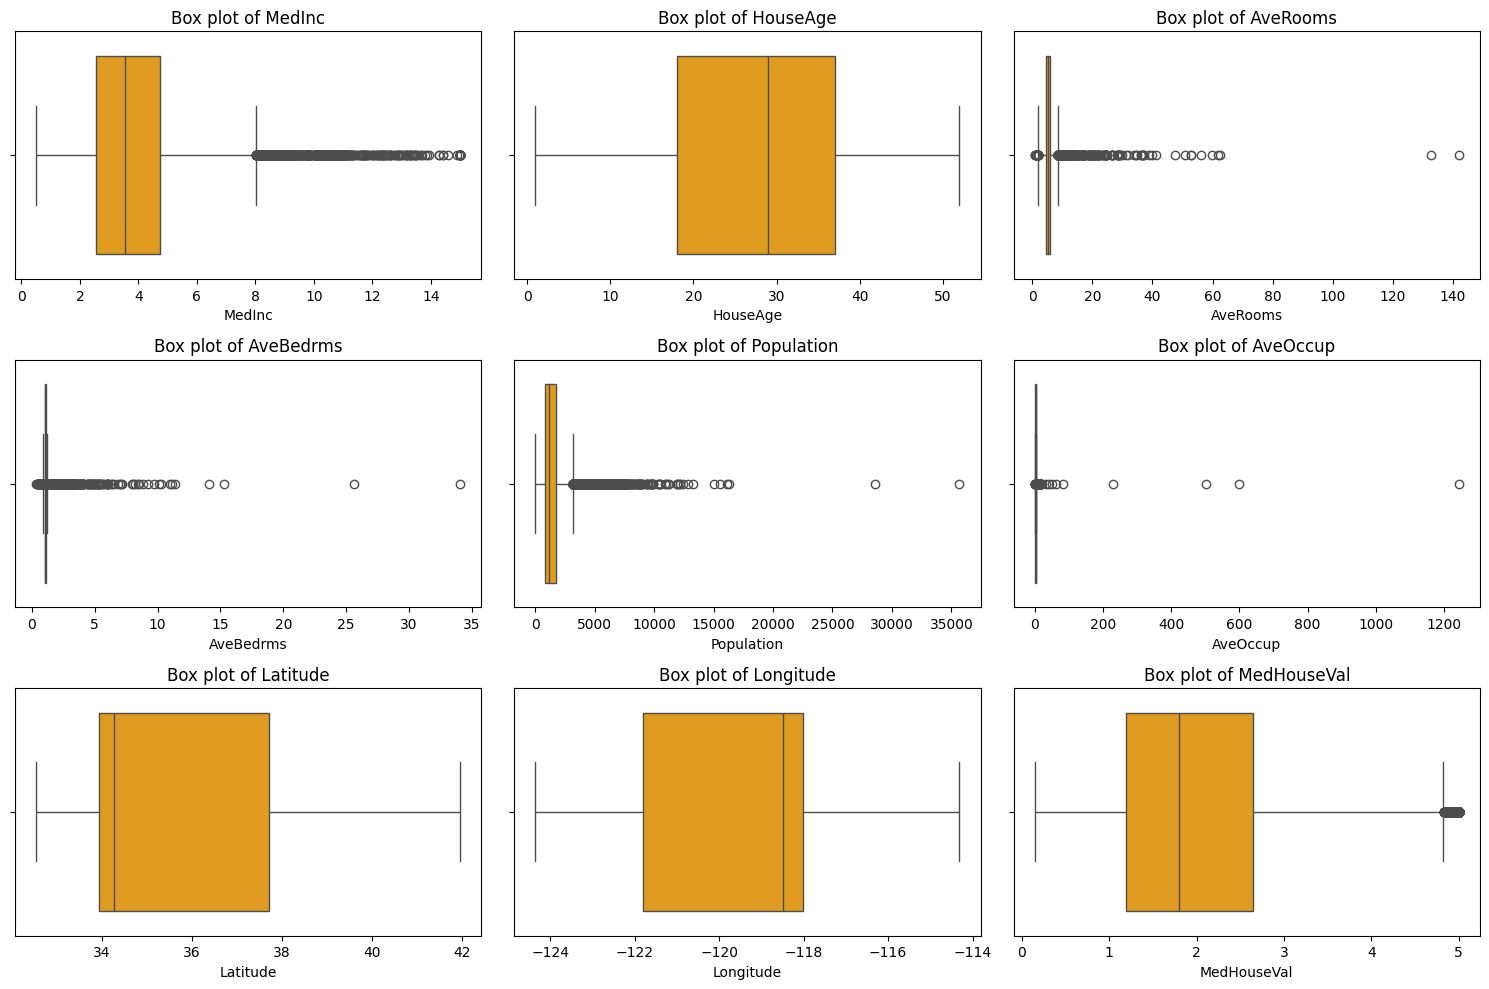

outliers Detection:
MedInc: 681outliers
HouseAge: 0outliers
AveRooms: 511outliers
AveBedrms: 1424outliers
Population: 1196outliers
AveOccup: 711outliers
Latitude: 0outliers
Longitude: 0outliers
MedHouseVal: 1071outliers

Dataset summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
data=fetch_california_housing(as_frame=True)
#print(data.frame.head())
housing_df=data.frame
numerical_features=housing_df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(15,10))
for i,feature in enumerate(numerical_features):
  plt.subplot(3,3,i+1)
  sns.histplot(housing_df[feature],kde=True,bins=30,color='blue')
  plt.title(f'Distributed of {feature}')
plt.tight_layout()
plt.show()
plt.figure(figsize=(15,10))
for i, feature in enumerate(numerical_features):
  plt.subplot(3,3,i+1)
  sns.boxplot(x=housing_df[feature],color='orange')
  plt.title(f'Box plot of {feature}')
plt.tight_layout()
plt.show()
print("outliers Detection:")
outliers_summary={}
for feature in numerical_features:
  Q1 = housing_df[feature].quantile(0.25)
  Q3 = housing_df[feature].quantile(0.75)
  IQR =Q3 -Q1
  lower_bound=Q1-1.5 *IQR
  upper_bound=Q3 +1.5 *IQR
  outliers=housing_df[(housing_df[feature]< lower_bound) |
                      (housing_df[feature] > upper_bound)]
  outliers_summary[feature]=len(outliers)
  print(f"{feature}: {len(outliers)}outliers")
print("\nDataset summary:")
print(housing_df.describe())

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load dataset
data = fetch_california_housing(as_frame=True)
housing_df = data.frame

# Select numerical features
numerical_features = housing_df.select_dtypes(include=[np.number]).columns

# =========================
# Histogram Plots
# =========================
plt.figure(figsize=(15,10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3,3,i+1)
    sns.histplot(housing_df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# =========================
# Box Plots
# =========================
plt.figure(figsize=(15,10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=housing_df[feature], color='orange')
    plt.title(f'Box plot of {feature}')
plt.tight_layout()
plt.show()

# =========================
# Outlier Detection
# =========================
print("Outliers Detection:")
outliers_summary = {}

for feature in numerical_features:
    Q1 = housing_df[feature].quantile(0.25)
    Q3 = housing_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = housing_df[
        (housing_df[feature] < lower_bound) |
        (housing_df[feature] > upper_bound)
    ]

    outliers_summary[feature] = len(outliers)
    print(f"{feature}: {len(outliers)} outliers")

# =========================
# Dataset Summary
# =========================
print("\nDataset summary:")
print(housing_df.describe())

# =====================================================
# EXTRA 1: Correlation Heatmap
# =====================================================
plt.figure(figsize=(12,8))
corr = housing_df[numerical_features].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

# =====================================================
# EXTRA 2: Scatter Plots (Features vs Target)
# =====================================================
target = 'MedHouseVal'

plt.figure(figsize=(15,10))
for i, feature in enumerate(numerical_features):
    if feature != target:
        plt.subplot(3,3,i+1)
        sns.scatterplot(
            x=housing_df[feature],
            y=housing_df[target],
            alpha=0.4
        )
        plt.xlabel(feature)
        plt.ylabel(target)

plt.tight_layout()
plt.show()
